# Task 1

In [3]:
graph = {
    "A": ["B", "C"],
    "B": ["D", "E"],
    "C": ["F"],
    "D": [],
    "E": [],
    "F": []
}
def bfs(start):
    visited = []
    queue = [start]

    while queue:
        node = queue.pop(0)

        if node not in visited:
            visited.append(node)
            for neighbor in graph[node]:
                queue.append(neighbor)

    return visited
def dfs(node, visited=[]):
    if node not in visited:
        visited.append(node)

        for neighbor in graph[node]:
            dfs(neighbor, visited)

    return visited
print("BFS:", bfs("A"))
print("DFS:", dfs("A"))

BFS: ['A', 'B', 'C', 'D', 'E', 'F']
DFS: ['A', 'B', 'D', 'E', 'C', 'F']


# TAsk 2


Running for size: 1000
BFS Time: 0.00559544563293457
DFS Time: 0.005473136901855469

Running for size: 5000
BFS Time: 0.1312398910522461
DFS Time: 0.12850093841552734

Running for size: 10000
BFS Time: 0.8512217998504639
DFS Time: 1.108154535293579

Running for size: 20000
BFS Time: 2.8455419540405273
DFS Time: 2.4346065521240234

Final Results:
1000 -> BFS: 0.00559544563293457 DFS: 0.005473136901855469
5000 -> BFS: 0.1312398910522461 DFS: 0.12850093841552734
10000 -> BFS: 0.8512217998504639 DFS: 1.108154535293579
20000 -> BFS: 2.8455419540405273 DFS: 2.4346065521240234


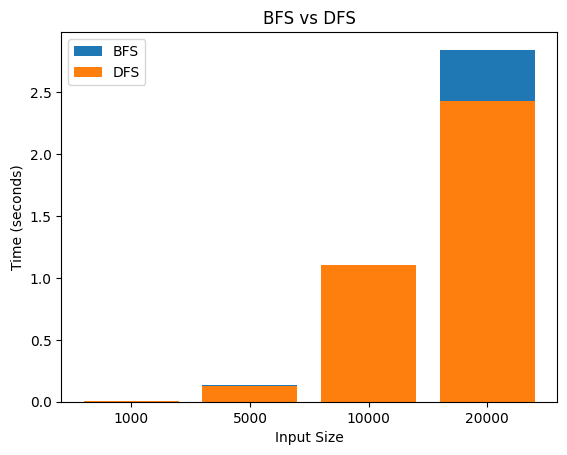

In [7]:
# ===== IMPORTS =====
import random
import time
import matplotlib.pyplot as plt

# ===== BFS =====
def bfs(graph, start):
    visited = []
    queue = [start]

    while queue:
        node = queue.pop(0)
        if node not in visited:
            visited.append(node)
            queue.extend(graph[node])
    return visited


# ===== DFS (FIXED - NO RECURSION) =====
def dfs(graph, start):
    visited = []
    stack = [start]

    while stack:
        node = stack.pop()   # last element (LIFO)

        if node not in visited:
            visited.append(node)
            for neighbor in graph[node]:
                stack.append(neighbor)

    return visited


# ===== TASK 2 =====

sizes = [1000, 5000, 10000, 20000]   # safe sizes

bfs_times = []
dfs_times = []

for size in sizes:
    print("\nRunning for size:", size)

    # Generate random data
    data = random.sample(range(size * 2), size)

    # Create simple chain graph
    graph2 = {}
    for i in range(len(data) - 1):
        graph2[data[i]] = [data[i + 1]]
    graph2[data[-1]] = []

    start_node = data[0]

    # ===== BFS TIME =====
    t1 = time.time()
    bfs(graph2, start_node)
    t2 = time.time()
    bfs_times.append(t2 - t1)

    print("BFS Time:", t2 - t1)

    # ===== DFS TIME =====
    t3 = time.time()
    dfs(graph2, start_node)
    t4 = time.time()
    dfs_times.append(t4 - t3)

    print("DFS Time:", t4 - t3)


# ===== RESULTS =====
print("\nFinal Results:")
for i in range(len(sizes)):
    print(sizes[i], "-> BFS:", bfs_times[i], "DFS:", dfs_times[i])


# ===== GRAPH =====
x = [str(s) for s in sizes]

plt.bar(x, bfs_times)
plt.bar(x, dfs_times)

plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS")

plt.legend(["BFS", "DFS"])

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# TAsk 3

In [5]:

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

def bfs(start, goal):
    queue = [[start]]
    visited = []

    while queue:
        path = queue.pop(0)
        city = path[-1]

        if city == goal:
            return path

        if city not in visited:
            for next_city in graph[city]:
                new_path = path.copy()
                new_path.append(next_city)
                queue.append(new_path)

            visited.append(city)

result = bfs("Islamabad", "Karachi")
print("Shortest Path:", result)

Shortest Path: ['Islamabad', 'Rawalpindi', 'Quetta', 'Karachi']
